In [1]:
!pip install gymnasium stable-baselines3

import numpy as np
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.4 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:

INITIAL_CASH = 10_000
MAX_INVENTORY = 10
TRADE_SIZE = 1

TRANSACTION_COST = 0.001
LAMBDA_RISK = 0.01

EPISODE_LENGTH = 1_000
SPREAD = 0.05
NUM_NOISE_TRADERS = 20
NOISE_TRADE_PROB = 0.05   # probability per trader per step


In [3]:

class SimpleOrderBook:
    def __init__(self, mid_price, spread=SPREAD):
        self.spread = spread
        self.mid_price = mid_price
        self.bid = mid_price - self.spread
        self.ask = mid_price + self.spread

    def update_price(self, new_mid):
        self.mid_price = new_mid
        self.bid = new_mid - self.spread
        self.ask = new_mid + self.spread

    def execute(self, side, size):
        if side == "buy":
            return self.ask
        elif side == "sell":
            return self.bid
        return None




In [4]:

class TradingEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, prices):
        super().__init__()

        self.prices = prices
        self.max_steps = EPISODE_LENGTH

        # Actions: Hold, Buy, Sell
        self.action_space = spaces.Discrete(3)

        # Observation: price, inventory, cash
        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(3,),
            dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.step_idx = 0
        self.cash = INITIAL_CASH
        self.inventory = 0
        self.prev_value = INITIAL_CASH

        self.order_book = SimpleOrderBook(self.prices[0])
        self.price_log = []
        self.value_log = []
        self.inventory_log = []


        return self._get_obs(), {}

    def step(self, action):
        mid_price = self.prices[self.step_idx]
        self.order_book.update_price(mid_price)

        exec_price = None
        if action == 1:
          exec_price = self.order_book.execute("buy", TRADE_SIZE)
        elif action == 2:
          exec_price = self.order_book.execute("sell", TRADE_SIZE)

        if exec_price is not None:
            if action == 1 and self.cash >= exec_price and self.inventory < MAX_INVENTORY:
                self.inventory += TRADE_SIZE
                self.cash -= exec_price * (1 + TRANSACTION_COST)

            elif action == 2 and self.inventory > 0:
                self.inventory -= TRADE_SIZE
                self.cash += exec_price * (1 - TRANSACTION_COST)

        for _ in range(NUM_NOISE_TRADERS):
            if np.random.rand() < NOISE_TRADE_PROB:
                side = np.random.choice(["buy", "sell"])
                self.order_book.execute(side, TRADE_SIZE)

        value = self.cash + self.inventory * mid_price
        pnl = value - self.prev_value

        reward = pnl - LAMBDA_RISK * abs(self.inventory)
        self.prev_value = value

        self.step_idx += 1
        terminated = self.step_idx >= self.max_steps
        truncated = False

        obs = self._get_obs()
        info = {
            "value": value,
            "inventory": self.inventory,
            "pnl": pnl,
            "bid": self.order_book.bid,
            "ask": self.order_book.ask
        }
        self.price_log.append(mid_price)
        self.value_log.append(value)
        self.inventory_log.append(self.inventory)

        return obs, reward, terminated, truncated, info

    def _get_obs(self):
      idx = min(self.step_idx, len(self.prices) - 1)

      price_norm = self.prices[idx] / self.prices[0]
      price_norm = np.clip(price_norm, 0.0, 1.0)

      inventory_norm = (self.inventory + MAX_INVENTORY) / (2 * MAX_INVENTORY)
      cash_norm = self.cash / INITIAL_CASH

      return np.array(
          [price_norm, inventory_norm, cash_norm],
          dtype=np.float32
      )




In [5]:

prices = np.cumsum(np.random.randn(EPISODE_LENGTH)) + 100

env = TradingEnv(prices)
check_env(env, warn=True)

obs, _ = env.reset()
total = 0

for _ in range(200):
    obs, r, d, _, _ = env.step(np.random.choice([1, 2]))
    total += r
    if d:
        break

print(total)
print("TRADE_SIZE:", TRADE_SIZE)
print("TRANSACTION_COST:", TRANSACTION_COST)
print("LAMBDA_RISK:", LAMBDA_RISK)
print("MAX_INVENTORY:", MAX_INVENTORY)


31.108135330914614
TRADE_SIZE: 1
TRANSACTION_COST: 0.001
LAMBDA_RISK: 0.01
MAX_INVENTORY: 10


In [6]:


model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=1
)

model.learn(total_timesteps=10_000)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -317     |
| time/              |          |
|    fps             | 960      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -278        |
| time/                   |             |
|    fps                  | 741         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008091373 |
|    clip_fraction        | 0.0398      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.000494   |
|    learning_rate        | 0.0003      |
|    loss                 | 283         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00279    |
|    value_loss           | 475         |
-----------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03 

In [7]:
def run_episode(env, policy_fn):
    obs, _ = env.reset()
    values = []

    done = False
    while not done:
        action = policy_fn(obs)
        obs, _, done, _, info = env.step(action)
        values.append(info["value"])

    return values


In [8]:
# Random agent
random_values = run_episode(
    env,
    lambda obs: env.action_space.sample()
)

# Buy & Hold agent
def buy_hold_policy(obs):
    return 1

buy_hold_values = run_episode(env, buy_hold_policy)

# PPO agent
ppo_values = run_episode(
    env,
    lambda obs: model.predict(obs, deterministic=True)[0]
)


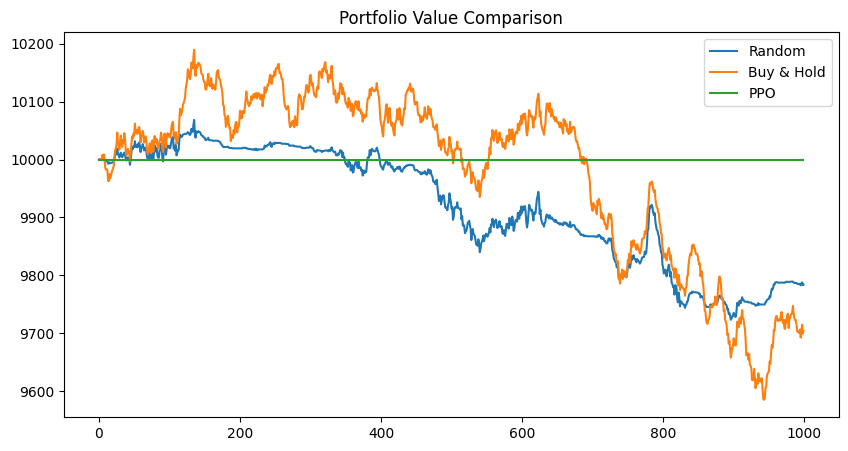

In [9]:
plt.figure(figsize=(10,5))
plt.plot(random_values, label="Random")
plt.plot(buy_hold_values, label="Buy & Hold")
plt.plot(ppo_values, label="PPO")
plt.legend()
plt.title("Portfolio Value Comparison")
plt.show()


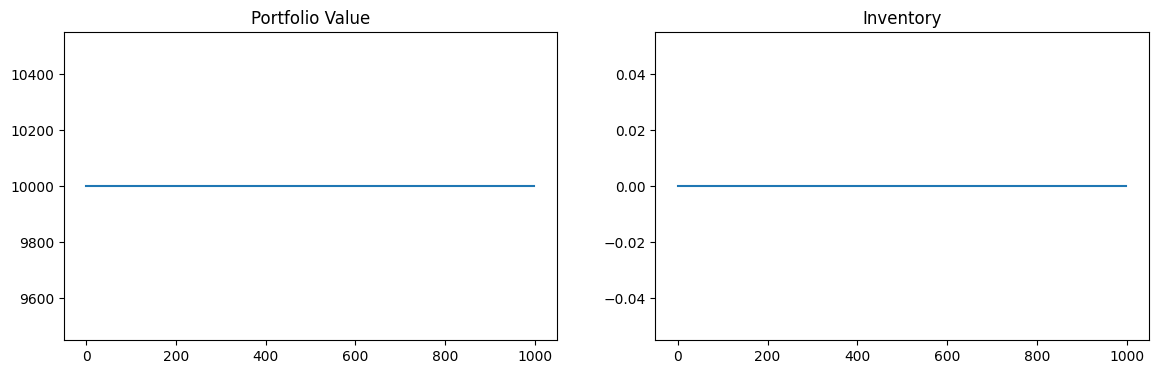

In [10]:

obs, _ = env.reset()

values = []
inventory = []

for _ in range(EPISODE_LENGTH):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)

    values.append(info["value"])
    inventory.append(info["inventory"])

    if done:
        break

plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.plot(values)
plt.title("Portfolio Value")

plt.subplot(1,2,2)
plt.plot(inventory)
plt.title("Inventory")

plt.show()
